In [608]:
import sys, os
import torch
import pandas as pd
import glob
from tqdm import tqdm
from omegaconf import OmegaConf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

local_user_path = '/home/jgershon/git/cleo' # change to your own path
sys.path.append(local_user_path) 
from ensemble import Ensemble
from data_util import FragmentDataset

### load model and check prediction accuracy

100%|██████████| 479/479 [00:01<00:00, 243.17it/s]


Model: mlp_all, mean Pearson r: 0.931
Model: mlp_all, UCB Pearson r: 0.930
Model: mlp_all, Rank of top true value by UCB: 171


100%|██████████| 479/479 [00:00<00:00, 485.48it/s]


Model: potts_all, mean Pearson r: 0.703
Model: potts_all, UCB Pearson r: 0.748
Model: potts_all, Rank of top true value by UCB: 204


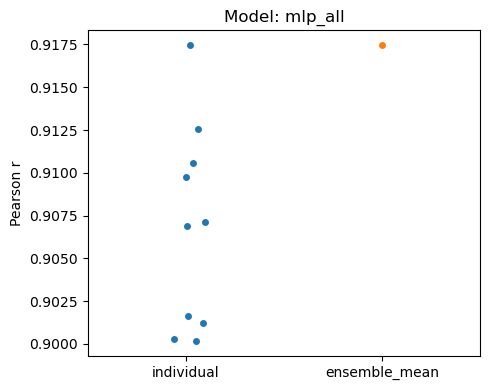

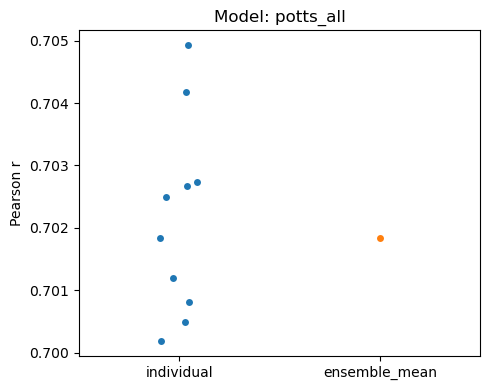

In [395]:
# path to model checkpoint

# models to evaluate
to_evaluate = [
    # (label, path)
    ("mlp_all", "/home/jgershon/git/cleo/ckpt/momi_test/momi_test.2025-12-11-11-58-37"),
    # ("mlp_round1", "/home/jgershon/git/cleo/ckpt/momi_mlp_round1_only/momi_mlp_round1_only.2025-12-11-13-48-21"),
    ("potts_all", "/home/jgershon/git/cleo/ckpt/momi_potts_test/momi_potts_test.2025-12-11-12-18-07"),
    # ("potts_round1", "/home/jgershon/git/cleo/ckpt/momi_potts_round1_only/momi_potts_round1_only.2025-12-11-13-58-01"),
]




for label, base_path in to_evaluate:
    

    ckpt_name = 'last.ckpt'

    ckpt = torch.load(os.path.join(base_path,ckpt_name), map_location=torch.device('cpu'))
    config = OmegaConf.load(os.path.join(base_path,'config.yaml'))

    # load model
    model = Ensemble(config)
    model.load_state_dict(ckpt['state_dict'])


    # get dataset
    dataset_path = os.path.join(local_user_path, config.data.dataset)
    data = pd.read_csv(dataset_path)
    
    data = data[data["val"]] # use only validation set for eval
    fragment_csv = None
    dataset = FragmentDataset(config.data.dataset_cfg, data)
    
    # run through the dataset
    y_true = []
    mu = []
    sigma = []
    pred_mean = []
    pred_var = []

    for x, y in tqdm(dataset):
        
        with torch.no_grad():
            
            output = model(x[None])
            mu.append(output["mu"].item())
            sigma.append(output["sigma"].item())
            pred_mean.append(output["mean"])
            pred_var.append(output["var"])
            y_true.append(y.item())

    # get corr
    y_true = np.array(y_true)
    mu = np.array(mu)
    sigma = np.array(sigma)



    corr, pval = stats.pearsonr(y_true, mu)
    print(f"Model: {label}, mean Pearson r: {corr:.3f}")

    # get ucb corr
    ucb = mu + sigma
    ucb_corr, ucb_pval = stats.pearsonr(y_true, ucb)
    print(f"Model: {label}, UCB Pearson r: {ucb_corr:.3f}")

    # find rank of top true value
    top_true_idx = np.argmax(y_true)
    ucb_sorted_indices = np.argsort(-ucb)  # Sort in descending order
    rank_of_top_true = np.where(ucb_sorted_indices == top_true_idx)[0][0] + 1  # +1 for 1-based rank
    print(f"Model: {label}, Rank of top true value by UCB: {rank_of_top_true}")

    # make plot comparing pearsonr for inidividual predictions and ensemble mean
    num_models = pred_mean[0].shape[1]

    individual_corrs = []
    for i in range(num_models):
        preds = np.array([x[0][i].item() for x in pred_mean])
        corr, _ = stats.pearsonr(y_true, preds)
        individual_corrs.append(corr)

    plt.figure(figsize=(5,4))
    sns.stripplot(x=["individual"]*num_models, y=individual_corrs)
    sns.stripplot(x=["ensemble_mean"], y=[corr])
    plt.ylabel("Pearson r")
    plt.title(f"Model: {label}")
    plt.tight_layout()

    

In [397]:
data

,serial_number,plate_number,sample_number,date_collected,replicate_number,sample_type,row,column,source_dna_well,sequence,...,mscarlett_um_mean,bg_sub_conc_norm_rate_mean,bg_sub_conc_norm_rate_std,bg_sub_conc_norm_rate_cv,mscarlett_num_pass,g20_norm_rate,momi_norm_rate,label,z_score_norm_rate,val
1913,21060423,2,1,251126,1,sample,E,6,E14,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEAI...,...,0.633940,1.007178e-05,6.153398e-07,0.005590,True,0.181034,2.172403,frag2,-0.391608,True
1914,21060423,3,1,251126,1,sample,I,2,I18,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.620360,1.711115e-05,7.392495e-07,0.006312,True,0.307562,3.690738,frag2,-0.030239,True
1915,21060423,2,1,251208,1,sample,L,8,L16,MGEQRTLWLERPSGERTPVYNHRYPARKAENGESAVANVRRLIEEI...,...,0.662700,3.128890e-07,1.087151e-07,0.001084,True,0.005624,0.067488,frag2,-0.892584,True
1916,21060423,3,2,251203,1,sample,C,4,C20,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.583080,5.935778e-07,5.071943e-07,0.005042,True,0.010669,0.128030,frag3,-0.878174,True
1917,21060423,3,1,251126,1,sample,F,8,F24,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.611572,1.191409e-05,1.259423e-06,0.011253,True,0.214148,2.569775,frag2,-0.297032,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,21060423,2,1,251126,1,sample,K,1,K9,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.598791,1.018934e-05,1.282719e-06,0.011641,True,0.183147,2.197758,frag2,-0.385573,True
2388,21060423,3,0,251208,1,sample,K,2,K18,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.597592,4.320315e-05,2.019126e-06,0.014100,True,0.776548,9.318572,frag1,1.309202,True
2389,21060423,1,1,251208,1,sample,F,7,F7,MGEEETLELERPSGKRTPVRRHEFPARKAANGESAIANVERLIEEI...,...,0.732600,5.853850e-06,6.644825e-07,0.006277,True,0.105219,1.262628,frag2,-0.608137,True
2390,21060423,3,1,251126,1,sample,C,4,C20,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.573227,9.851435e-06,1.049948e-06,0.009558,True,0.177073,2.124875,frag2,-0.402919,True


In [ ]:


x.shape

torch.Size([479, 1, 10, 1])

<Axes: >

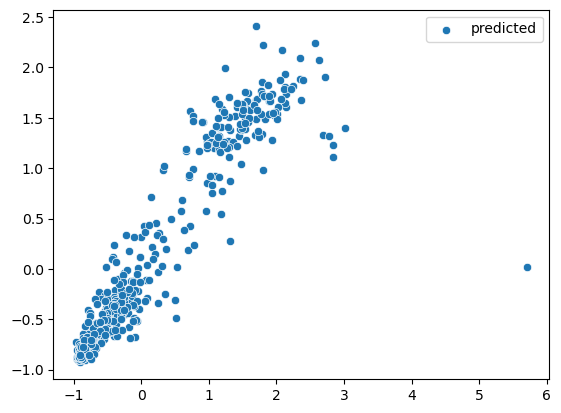

In [181]:
sns.scatterplot(x=y_true, y=np.array(mu), label='predicted')

### predicting over full dataset

 15%|█▍        | 348/2392 [00:01<00:07, 283.04it/s]

100%|██████████| 2392/2392 [00:08<00:00, 281.85it/s]


Model: mlp_no_val, mean Pearson r: 0.966
Model: mlp_no_val, UCB Pearson r: 0.964
Model: mlp_no_val, Rank of top true value by UCB: 398


100%|██████████| 2392/2392 [00:04<00:00, 500.93it/s]


Model: potts_no_val, mean Pearson r: 0.739
Model: potts_no_val, UCB Pearson r: 0.752
Model: potts_no_val, Rank of top true value by UCB: 668


100%|██████████| 3072/3072 [00:10<00:00, 283.95it/s]


Model: momi_round2_no_val, mean Pearson r: 0.954
Model: momi_round2_no_val, UCB Pearson r: 0.953
Model: momi_round2_no_val, Rank of top true value by UCB: 19


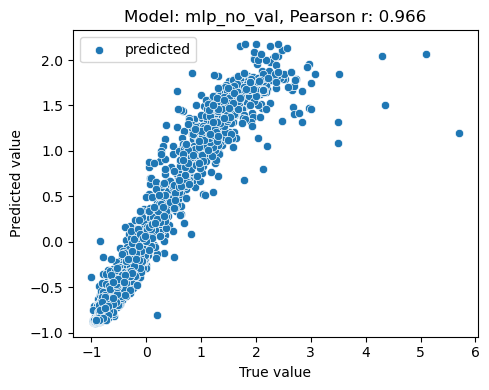

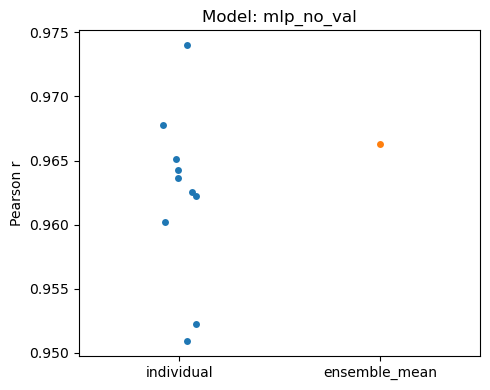

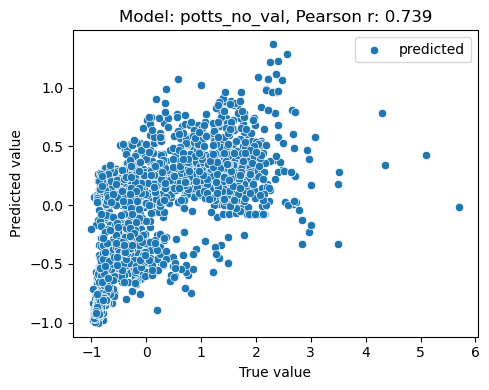

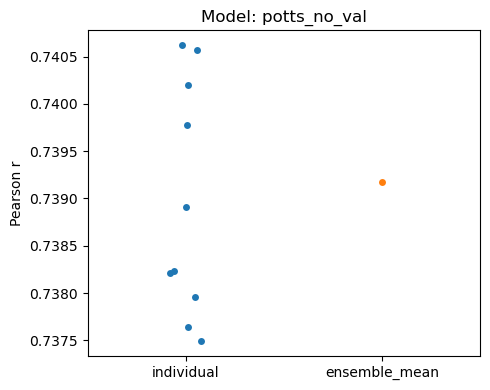

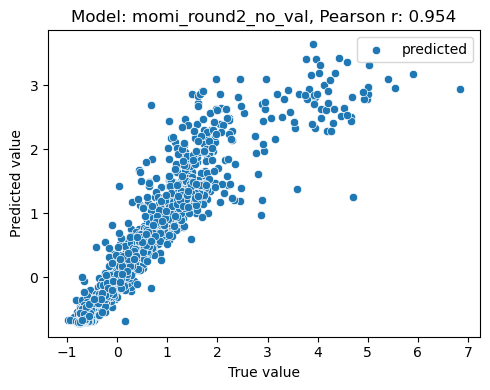

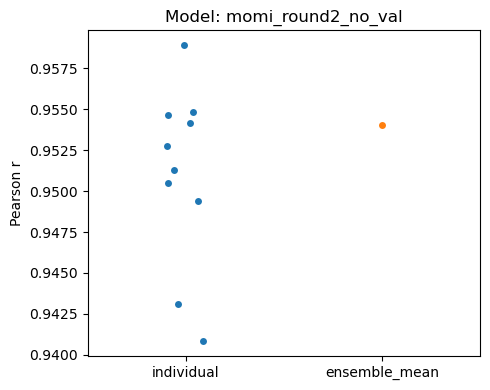

In [784]:
# path to model checkpoint

# models to evaluate
to_evaluate = [
    # (label, path)
    ("mlp_no_val", "/home/jgershon/git/cleo/ckpt/momi_mlp_no_val/momi_mlp_no_val.2025-12-15-22-18-23"),
    ("potts_no_val", "/home/jgershon/git/cleo/ckpt/momi_potts_no_val/momi_potts_no_val.2025-12-15-20-07-58"),
    ("momi_round2_no_val", "/home/jgershon/git/cleo/ckpt/momi_round2_mlp_no_val/momi_round2_mlp_no_val.2025-12-18-23-21-46")
]

base = "/home/jgershon/git/cleo/"

for label, base_path in to_evaluate:
    


    ckpt_name = 'last.ckpt'

    ckpt = torch.load(os.path.join(base_path,ckpt_name), map_location=torch.device('cpu'))
    config = OmegaConf.load(os.path.join(base_path,'config.yaml'))

    # load model
    model = Ensemble(config)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()


    # get dataset
    dataset_path = os.path.join(base, config.data.dataset)
    data = pd.read_csv(dataset_path)
    
    fragment_csv = None
    dataset = FragmentDataset(config.data.dataset_cfg, data)
    
    # run through the dataset
    y_true = []
    mu = []
    sigma = []
    pred_mean = []
    pred_var = []

    for x, y in tqdm(dataset):
        
        with torch.no_grad():
            
            output = model(x[None])
            mu.append(output["mu"].item())
            sigma.append(output["sigma"].item())
            pred_mean.append(output["mean"])
            pred_var.append(output["var"])
            y_true.append(y.item())

    # get corr
    y_true = np.array(y_true)
    mu = np.array(mu)
    sigma = np.array(sigma)

    corr, pval = stats.pearsonr(y_true, mu)
    print(f"Model: {label}, mean Pearson r: {corr:.3f}")

    # get ucb corr
    ucb = mu + sigma
    ucb_corr, ucb_pval = stats.pearsonr(y_true, ucb)
    print(f"Model: {label}, UCB Pearson r: {ucb_corr:.3f}")

    # find rank of top true value
    top_true_idx = np.argmax(y_true)
    ucb_sorted_indices = np.argsort(-ucb)  # Sort in descending order
    rank_of_top_true = np.where(ucb_sorted_indices == top_true_idx)[0][0] + 1  # +1 for 1-based rank
    print(f"Model: {label}, Rank of top true value by UCB: {rank_of_top_true}")

    # make plot comparing pearsonr for inidividual predictions and ensemble mean
    num_models = pred_mean[0].shape[1]

    individual_corrs = []
    for i in range(num_models):
        preds = np.array([x[0][i].item() for x in pred_mean])
        corr, _ = stats.pearsonr(y_true, preds)
        individual_corrs.append(corr)

    # plot predicted vs true
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=y_true, y=np.array(mu), label='predicted')
    plt.xlabel("True value")
    plt.ylabel("Predicted value")
    plt.title(f"Model: {label}, Pearson r: {stats.pearsonr(y_true, mu)[0]:.3f}")
    plt.tight_layout()

    # plot comparison between individual and ensemble
    plt.figure(figsize=(5,4))
    sns.stripplot(x=["individual"]*num_models, y=individual_corrs)
    sns.stripplot(x=["ensemble_mean"], y=[stats.pearsonr(y_true, mu)[0]])
    plt.ylabel("Pearson r")
    plt.title(f"Model: {label}")
    plt.tight_layout()

    

    

In [787]:
data

,serial_number,plate_number,sample_number,date_collected,replicate_number,sample_type,row,column,source_dna_well,sequence,...,mscarlett_um_mean,bg_sub_conc_norm_rate_mean,bg_sub_conc_norm_rate_std,bg_sub_conc_norm_rate_cv,mscarlett_num_pass,g20_norm_rate,momi_norm_rate,label,z_score_norm_rate,val
0,21060423,2,1,251218,1,sample,E,5,E13,MGWEEDLWLERPSGERTPVRRHHFPAKKAENGESAIANVERLIEEI...,...,0.642728,1.129177e-04,3.326880e-06,0.015625,True,2.107830,25.293958,frag2,4.026865,False
1,21060423,2,0,251218,1,sample,J,3,J11,MGEEEELYLERPSGERTPVHRHRVPAEKANNFDEAVANYERLIEEI...,...,0.529289,1.091451e-06,7.815843e-07,0.007731,True,0.020374,0.244489,frag1,-0.702199,False
2,21060423,3,0,251208,1,sample,K,7,K23,MGWEEDLWLERPSGERTPVRRAVFPARKAENGESAVANVERLIEEI...,...,0.356735,5.290235e-05,1.747416e-06,0.011428,True,0.987526,11.850312,frag1,1.488852,False
3,21060423,3,0,251208,1,sample,P,1,P17,MGTEETLWLERPSGERTPVRRYEYPARKAANGESAIANVERLIEEI...,...,0.607977,2.206355e-05,1.187283e-06,0.009727,True,0.411859,4.942312,frag1,0.184698,False
4,21060423,2,0,251125,1,sample,H,3,H11,MGEEEELELERPSGERTPVRRHRVYARKAGNFEEAVANHERLIEEI...,...,0.675215,5.258780e-06,1.601069e-07,0.001521,True,0.098165,1.177985,frag1,-0.525966,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3067,21060423,1,2,251203,1,sample,N,7,N7,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.595329,1.588333e-07,3.410996e-07,0.003406,True,0.002965,0.035579,frag3,-0.741639,True
3068,21060423,3,1,251218,1,sample,M,6,M22,GFEEEELELERESGQVTPVRRHRVPARKANNFDEAVRNMERLIEAV...,...,0.379902,9.277509e-07,2.192042e-06,0.021719,True,0.017318,0.207819,frag2,-0.709122,True
3069,21060423,2,3,251203,1,sample,I,4,I12,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.351942,5.091978e-05,2.125357e-06,0.014083,True,0.950517,11.406210,frag4,1.405011,True
3070,21060423,2,1,251208,1,sample,D,6,D14,MGEVEELWLERPSGERTPVVRHTFPARKAENGESAVANVERLIEEI...,...,0.692257,1.896937e-05,4.751362e-07,0.003994,True,0.354100,4.249205,frag2,0.053847,True


In [788]:
data[data["source_dna_well"] == "P23"]

,serial_number,plate_number,sample_number,date_collected,replicate_number,sample_type,row,column,source_dna_well,sequence,...,mscarlett_um_mean,bg_sub_conc_norm_rate_mean,bg_sub_conc_norm_rate_std,bg_sub_conc_norm_rate_cv,mscarlett_num_pass,g20_norm_rate,momi_norm_rate,label,z_score_norm_rate,val
17,21060423,1,0,251125,1,positive_control,P,5,P23,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.624620,0.000055,2.159891e-06,0.013938,True,1.026096,12.313157,frag1,1.576233,False
194,21060423,1,0,251208,1,positive_control,P,5,P23,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.685467,0.000058,1.599226e-06,0.010126,True,1.081452,12.977427,frag1,1.701640,False
239,21060423,2,1,251218,1,positive_control,P,5,P23,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.453398,0.000047,3.582584e-06,0.024379,True,0.876508,10.518095,frag2,1.237345,False
353,21060423,1,1,251208,1,positive_control,P,5,P23,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.598391,0.000055,1.592396e-06,0.010250,True,1.033374,12.400491,frag2,1.592720,False
516,21060423,1,2,251203,1,positive_control,P,5,P23,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.582014,0.000056,1.519816e-06,0.009718,True,1.052776,12.633309,frag3,1.636674,False
537,21060423,1,3,251203,1,positive_control,P,5,P23,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.617431,0.000056,9.541333e-07,0.006107,True,1.049604,12.595252,frag4,1.629489,False
689,21060423,3,1,251208,1,positive_control,P,5,P23,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.563641,0.000060,1.576054e-06,0.009868,True,1.114553,13.374638,frag2,1.776628,False
726,21060423,2,1,251126,1,positive_control,P,5,P23,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.629547,0.000045,1.139176e-06,0.007868,True,0.835918,10.031021,frag2,1.145390,False
825,21060423,3,0,251125,1,positive_control,P,5,P23,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.633142,0.000054,2.476489e-06,0.016128,True,0.999636,11.995637,frag1,1.516288,False
899,21060423,3,0,251218,1,positive_control,P,5,P23,MGEEEELELERPSGERTPVRRHRFPARKANNIEEAVANVERLIEEI...,...,0.603983,0.000046,2.267416e-06,0.015521,True,0.860217,10.322600,frag1,1.200437,False


### potts model params

In [655]:
fragment_bounds = [[0, 41], [42, 85], [86, 127], [128, 164], [165, 208]]

base_path =  "/home/jgershon/git/cleo/ckpt/momi_potts_no_val/momi_potts_no_val.2025-12-15-20-07-58"

ckpt_name = 'last.ckpt'

ckpt = torch.load(os.path.join(base_path,ckpt_name), map_location=torch.device('cpu'))
config = OmegaConf.load(os.path.join(base_path,'config.yaml'))

# load model
model = Ensemble(config)
model.load_state_dict(ckpt['state_dict'])

<All keys matched successfully>

In [672]:
hue_list = []
for i,(a,b) in enumerate(fragment_bounds):
    hue_list.extend([f"frag{i+1}"]*(((1+b)-a)*20))

In [673]:
len(hue_list)

4180

In [674]:
x.shape

torch.Size([4180])

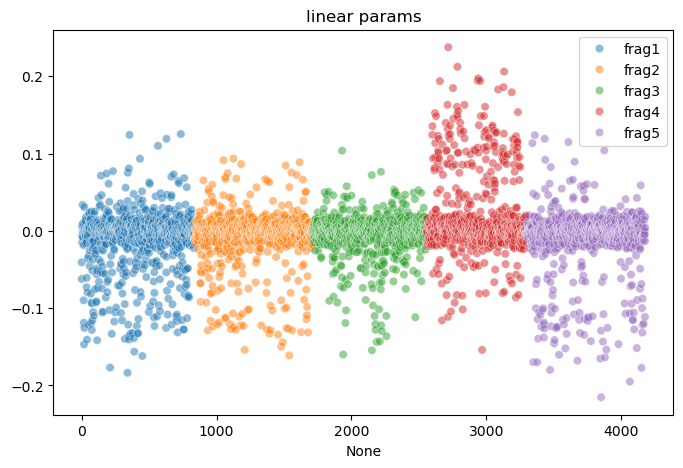

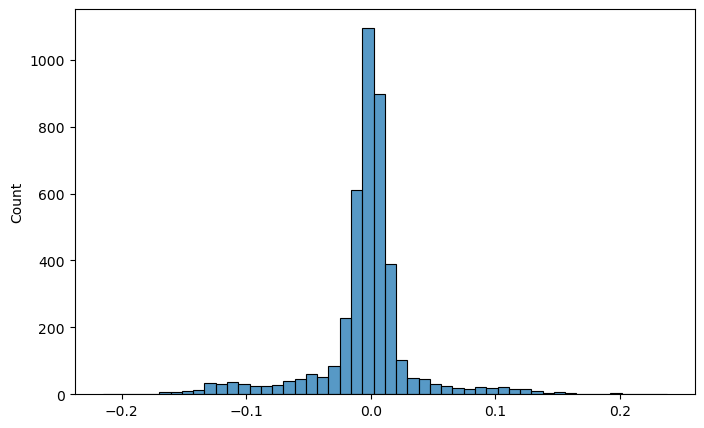

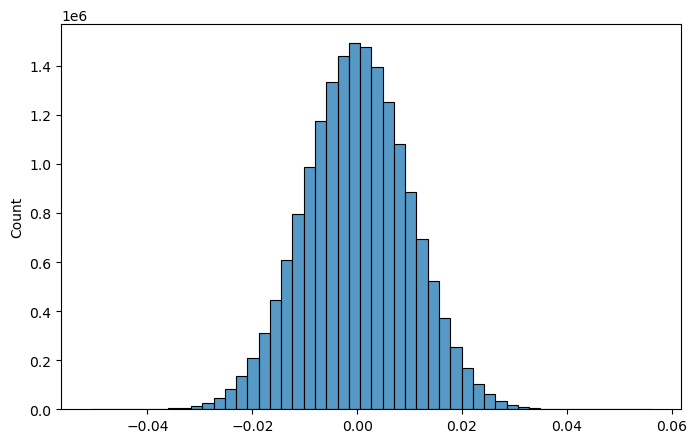

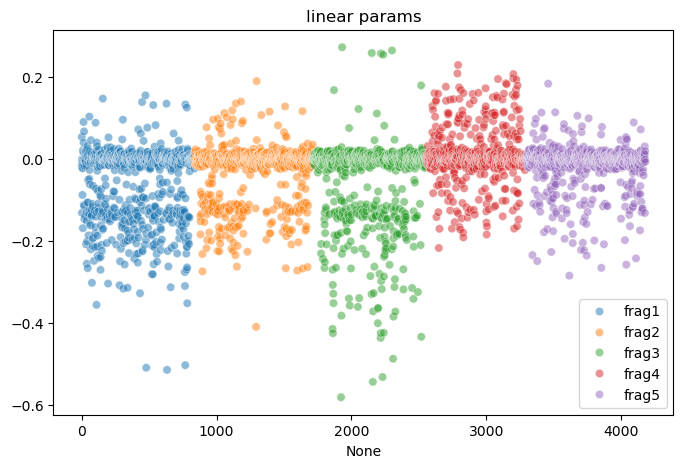

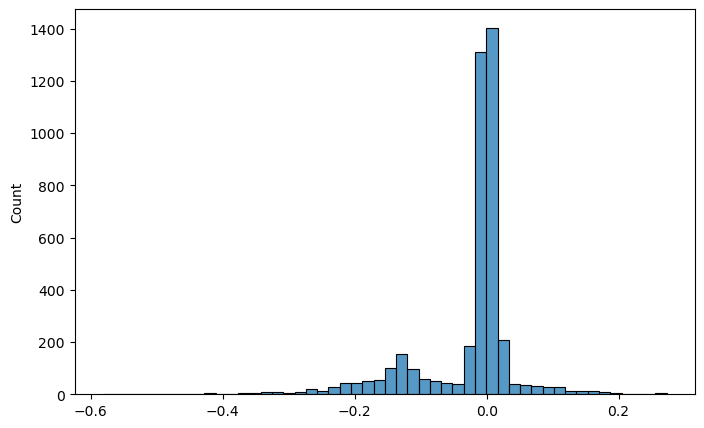

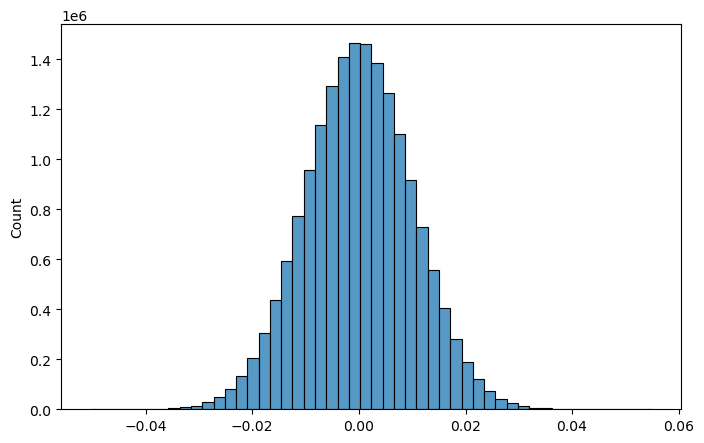

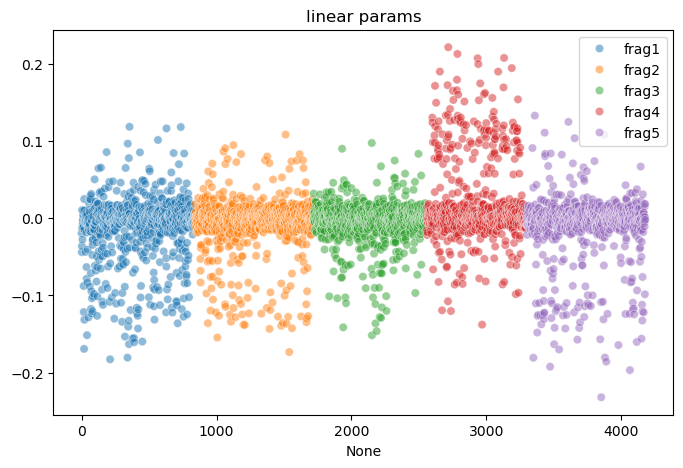

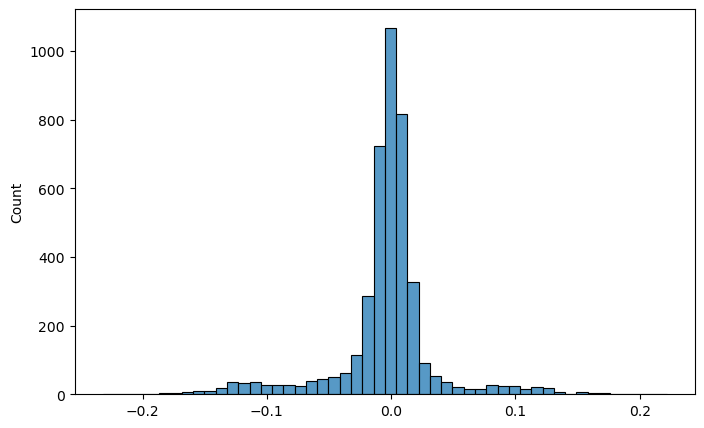

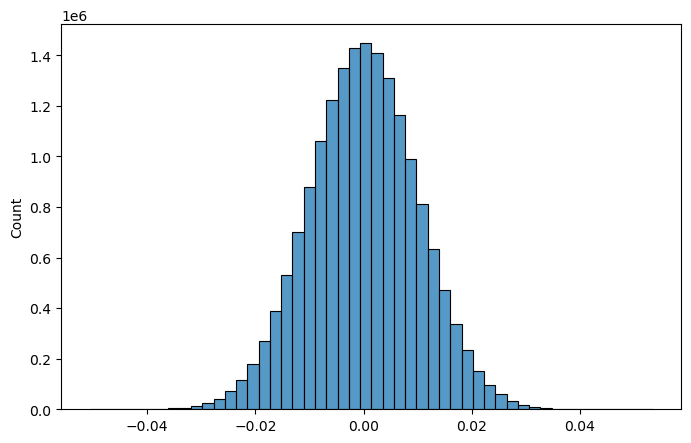

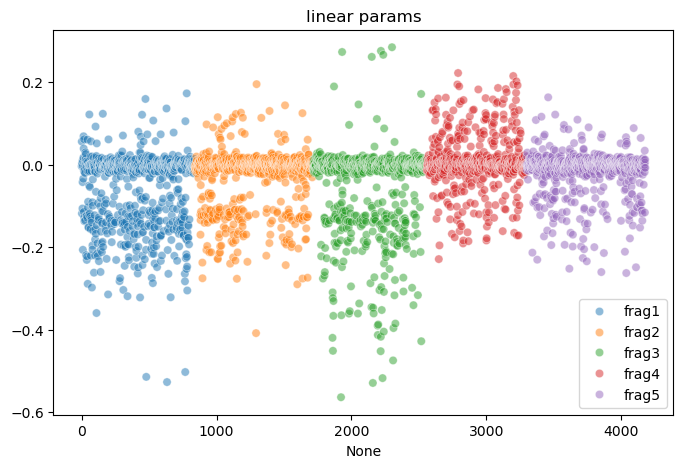

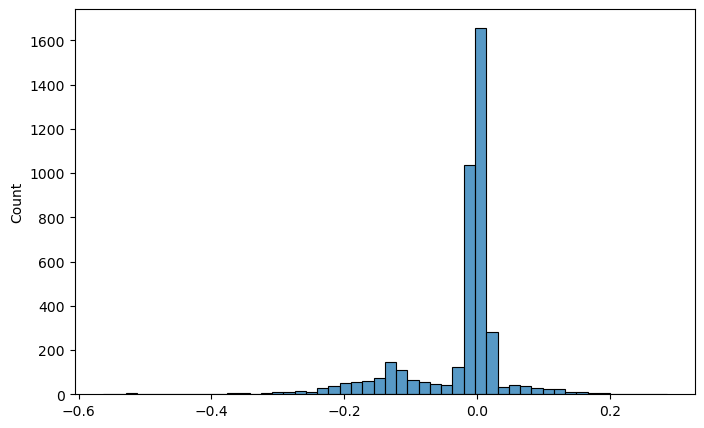

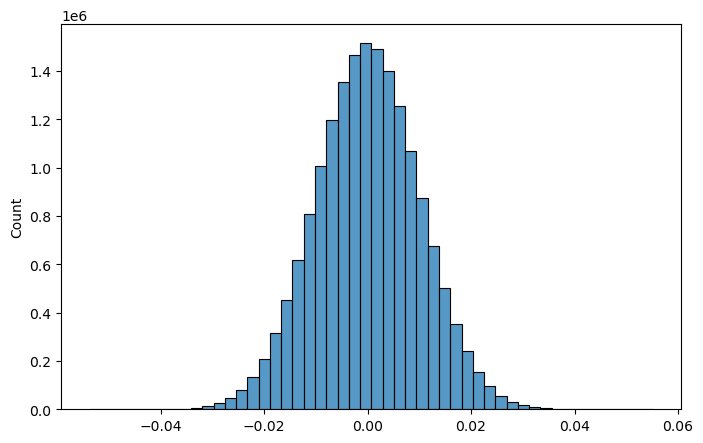

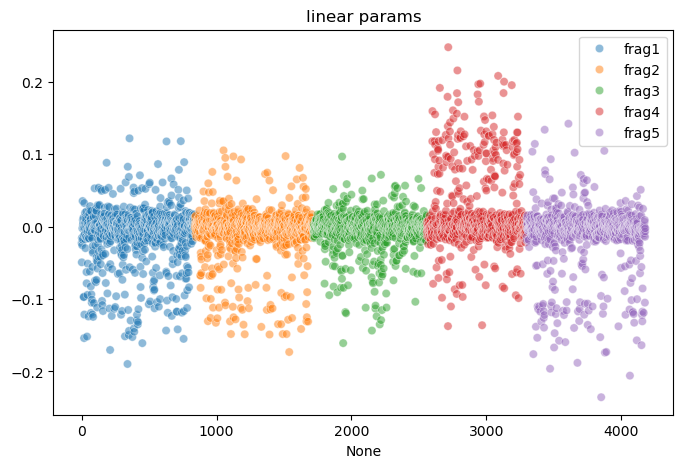

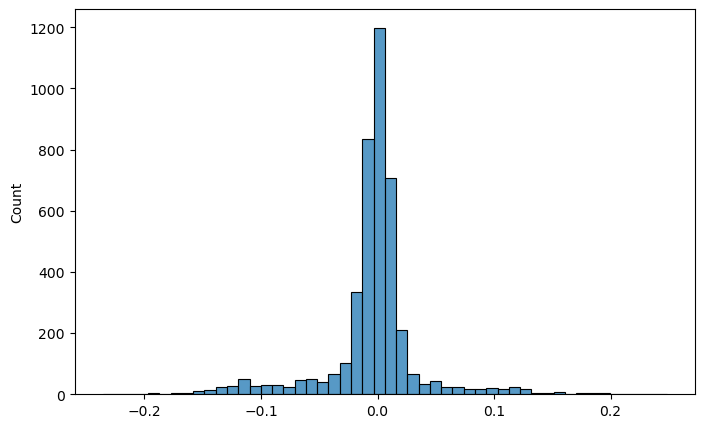

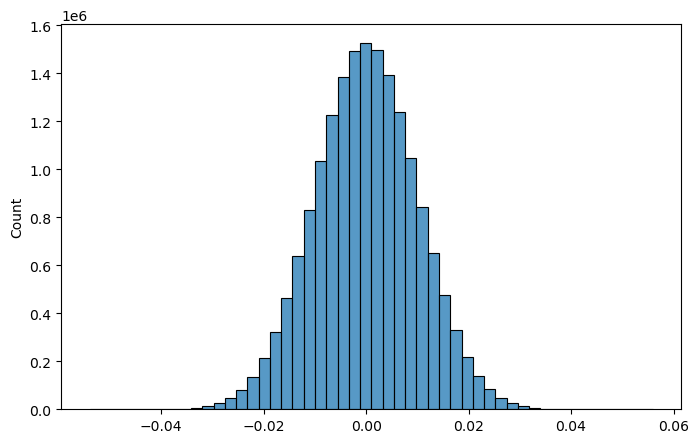

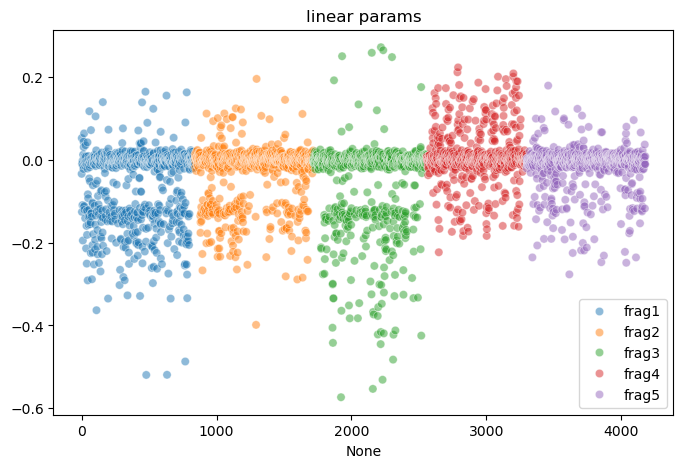

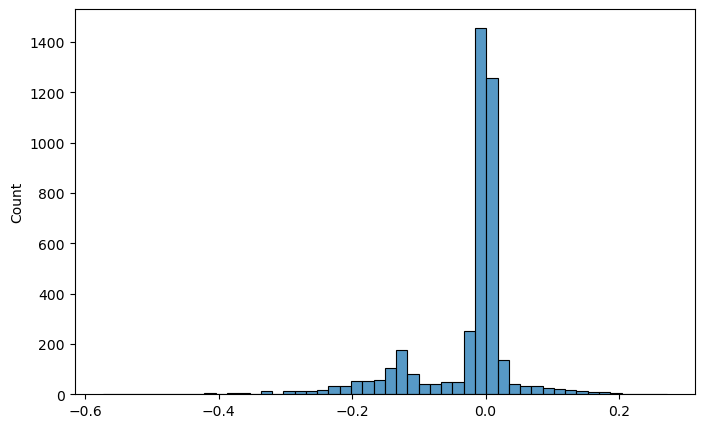

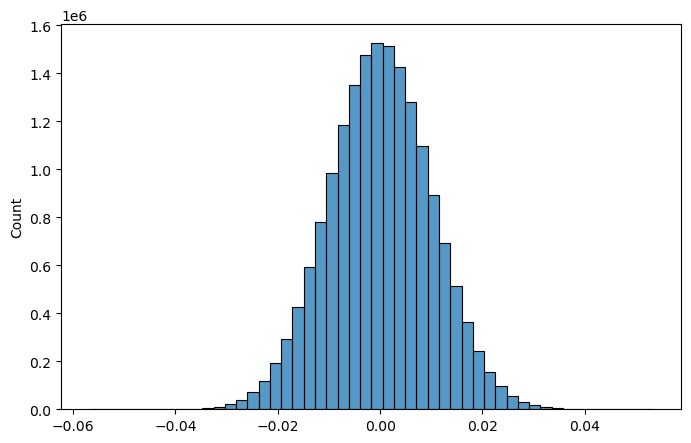

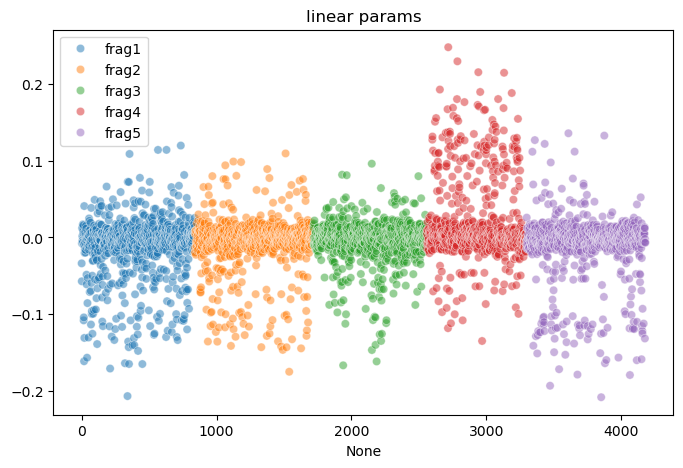

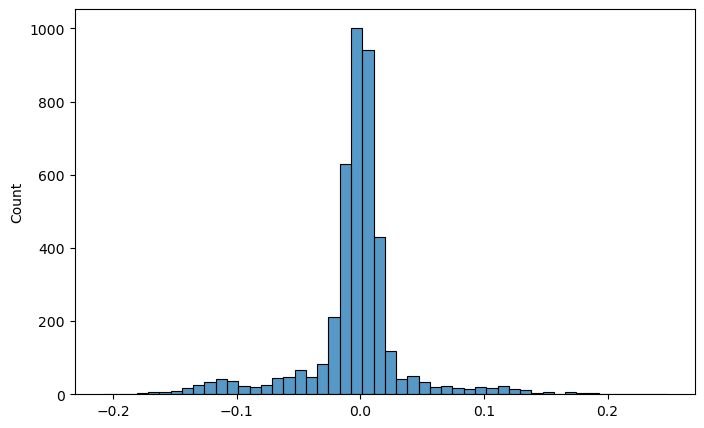

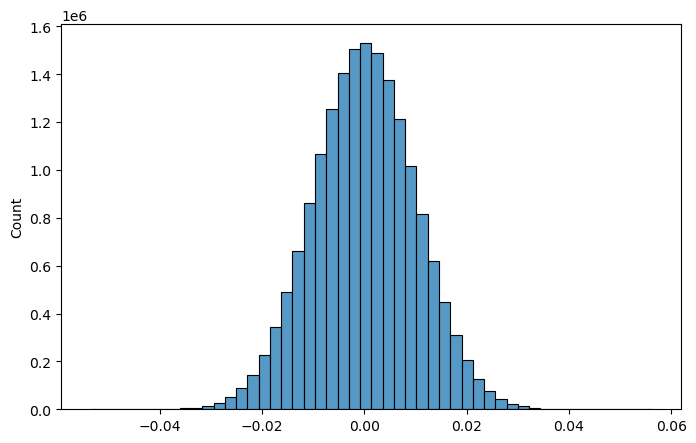

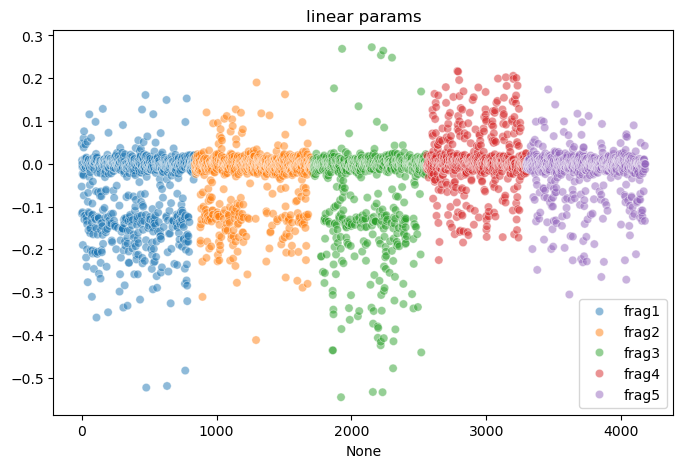

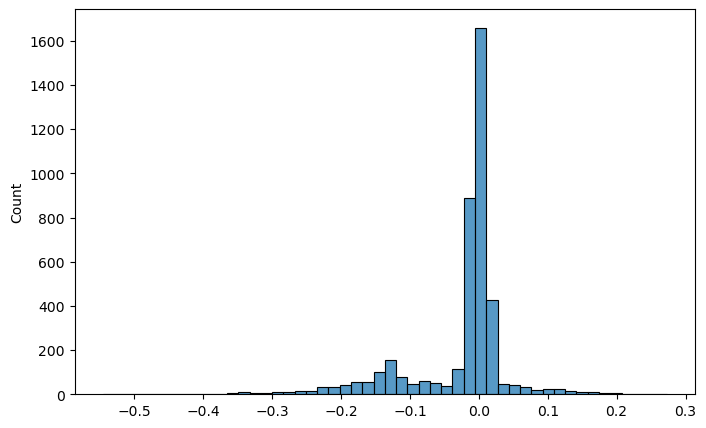

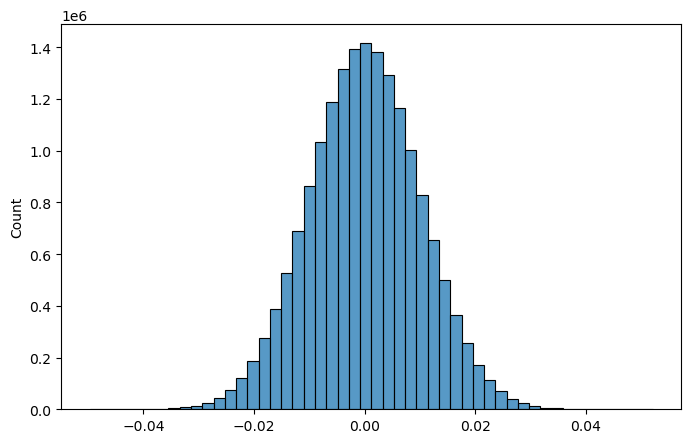

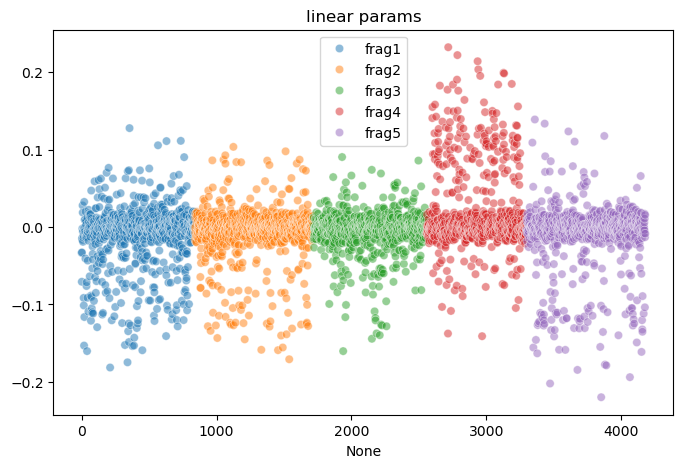

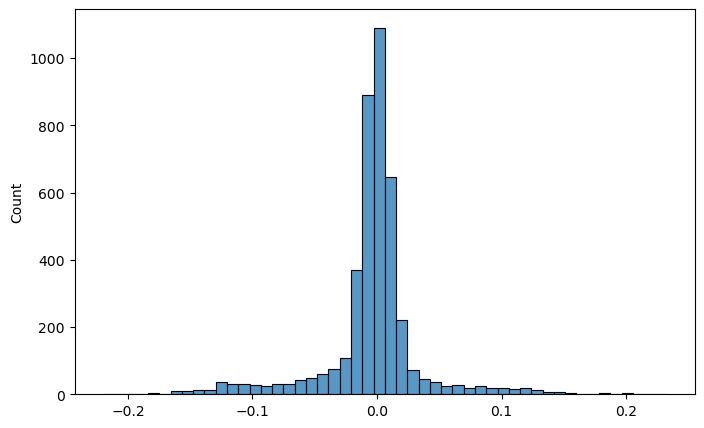

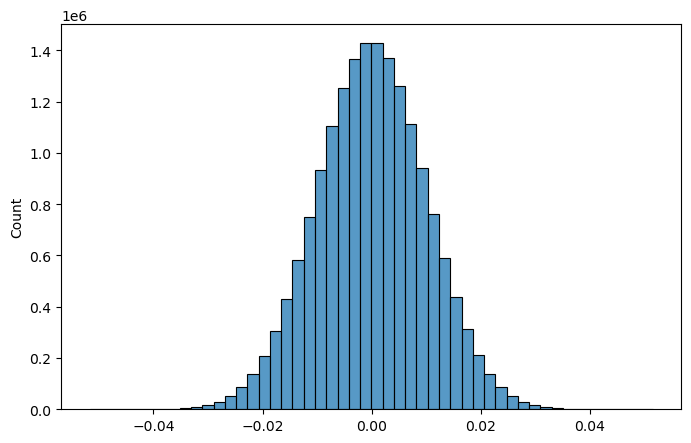

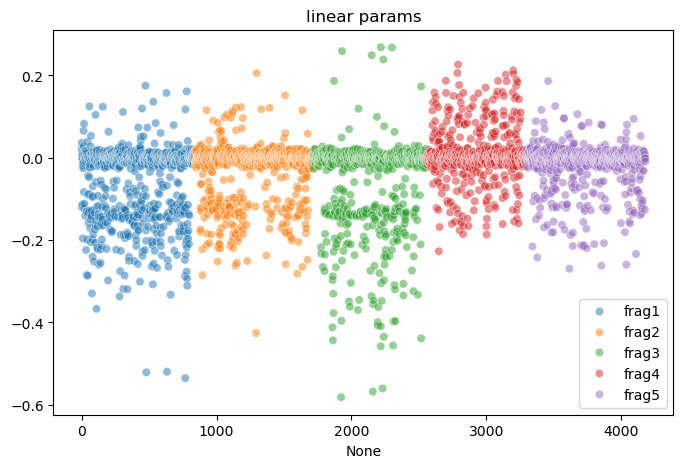

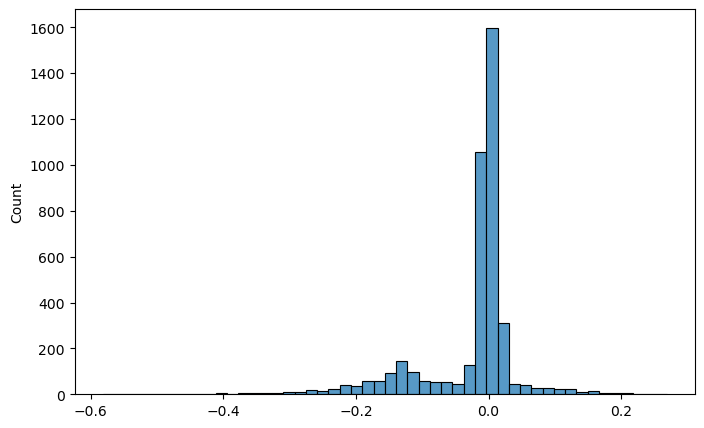

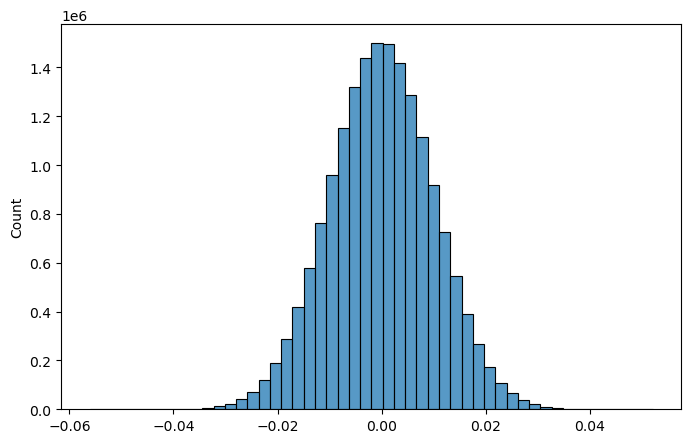

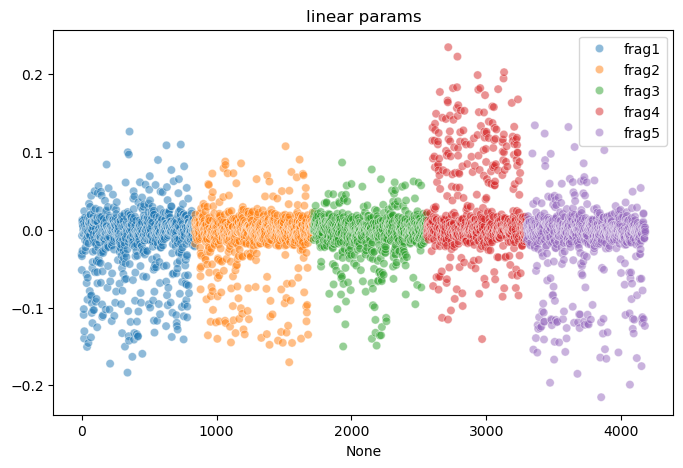

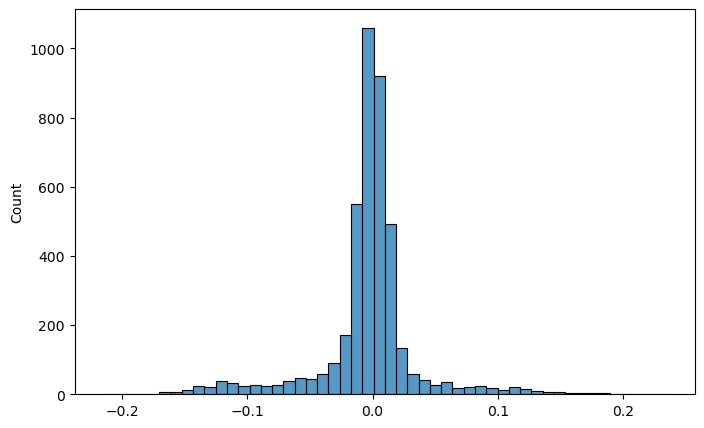

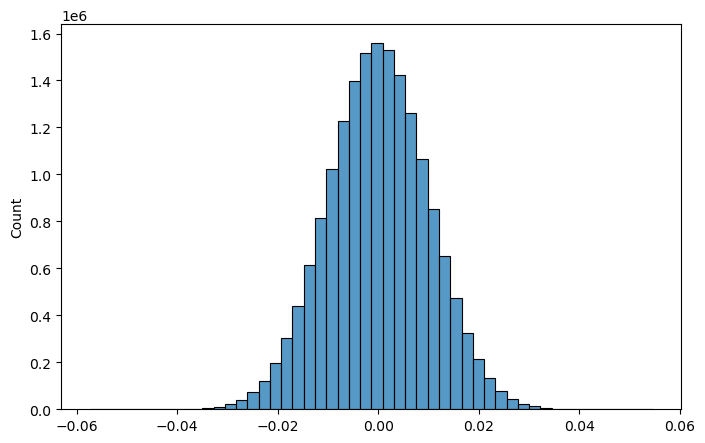

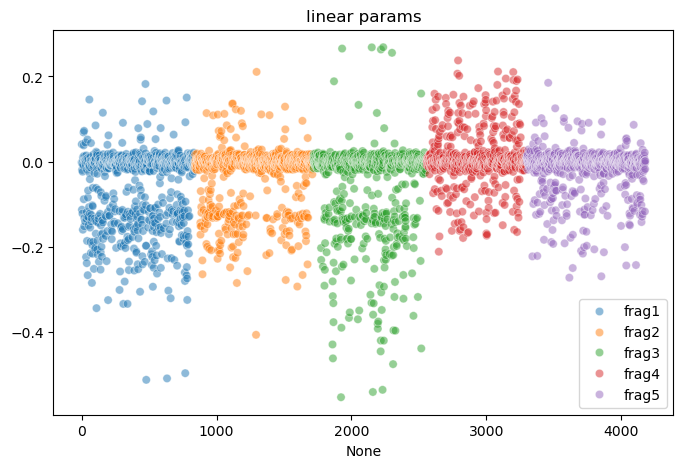

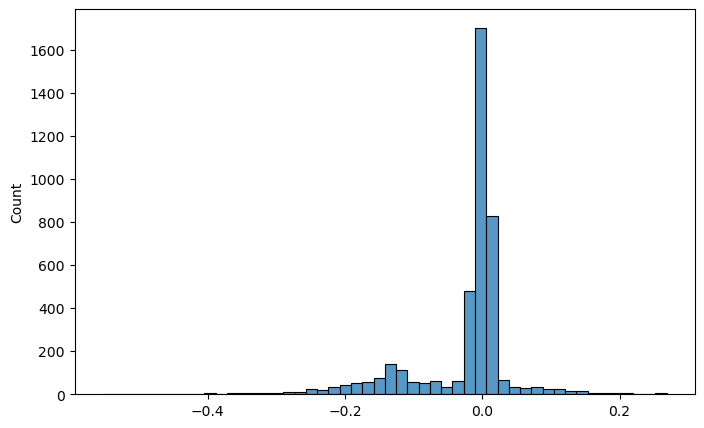

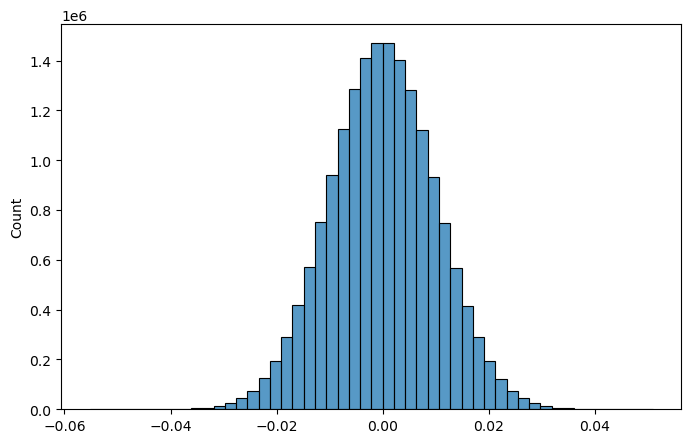

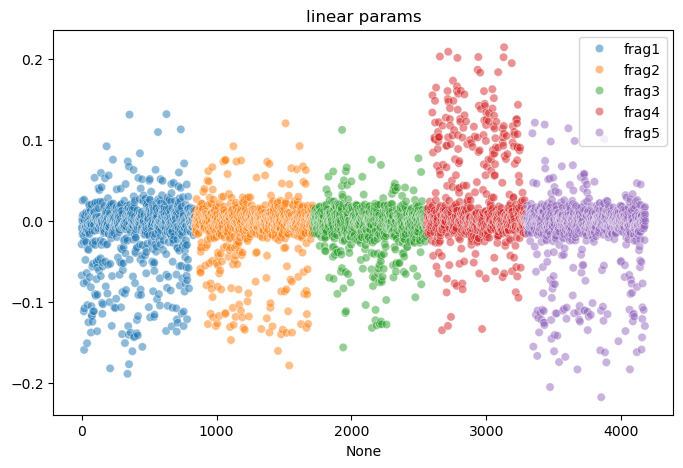

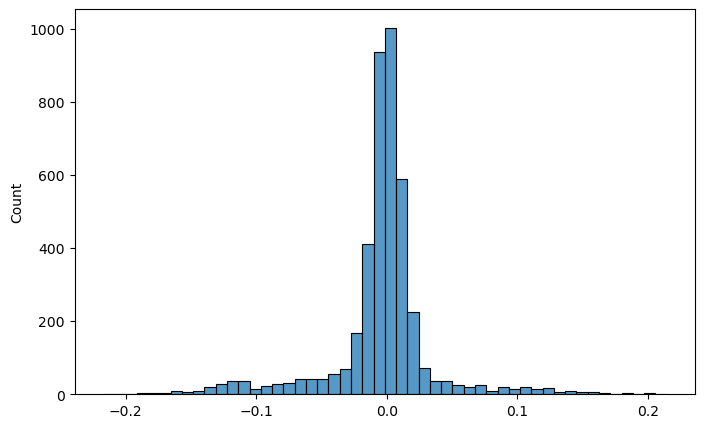

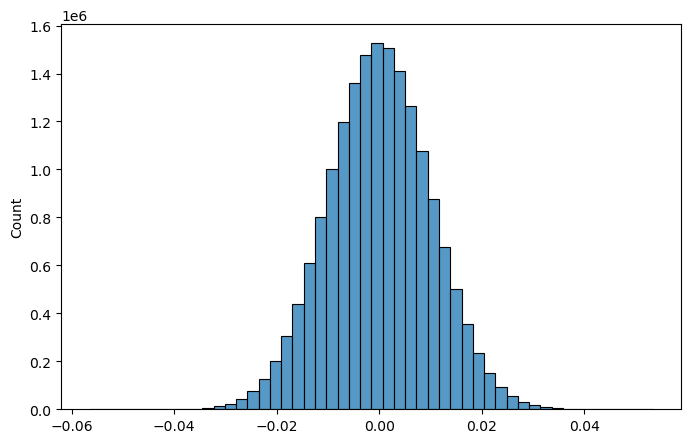

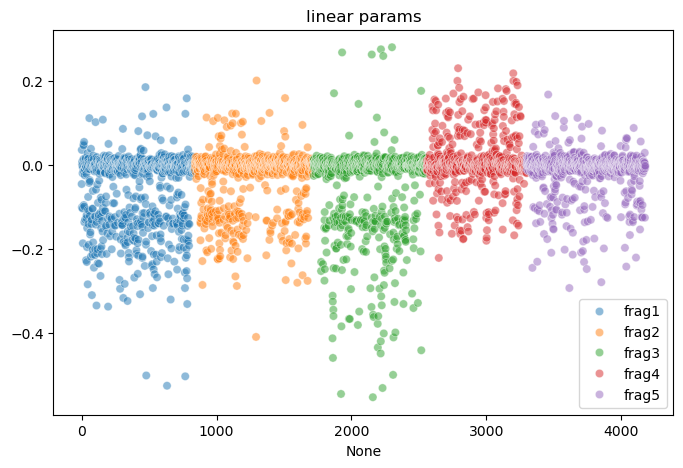

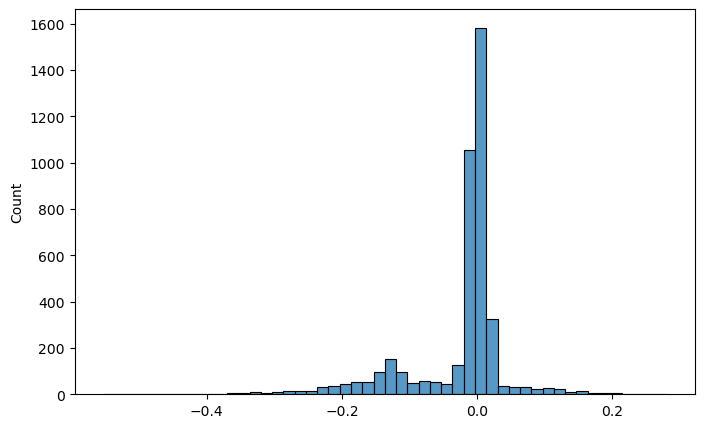

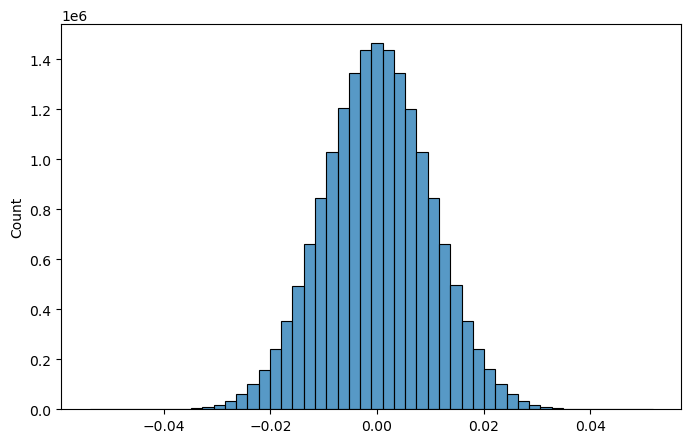

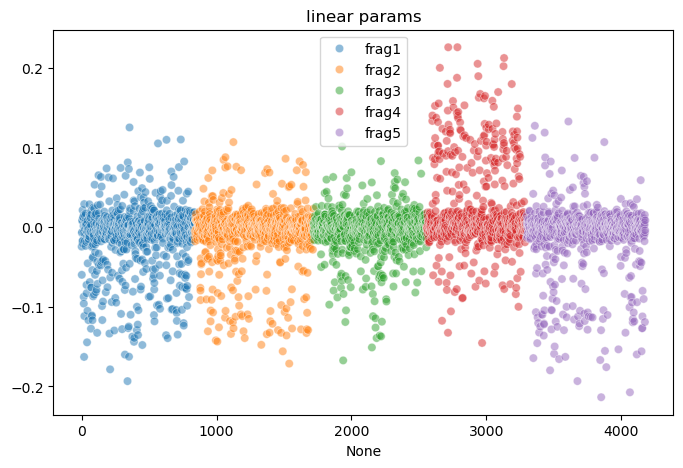

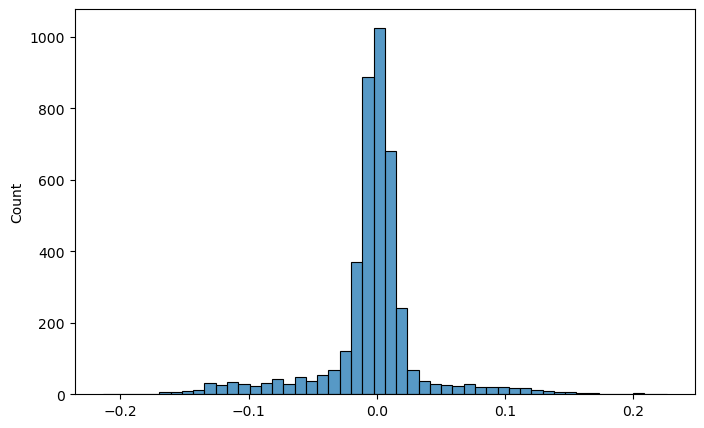

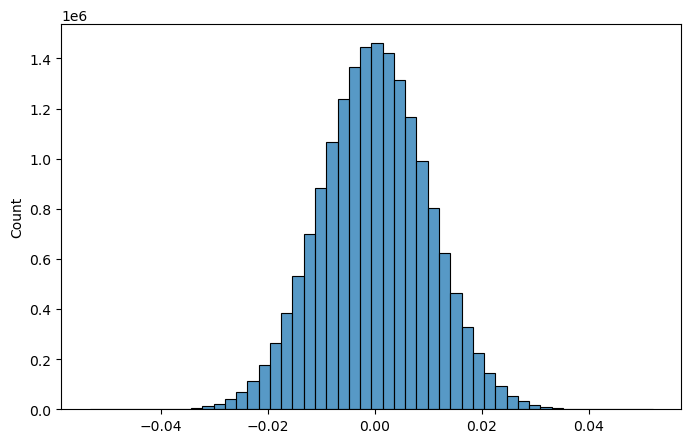

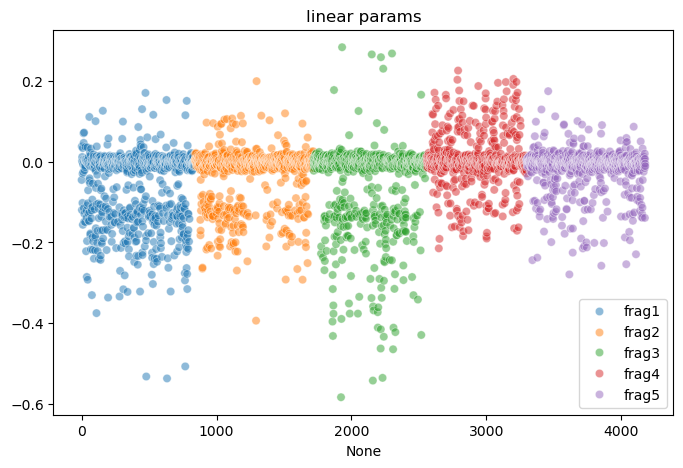

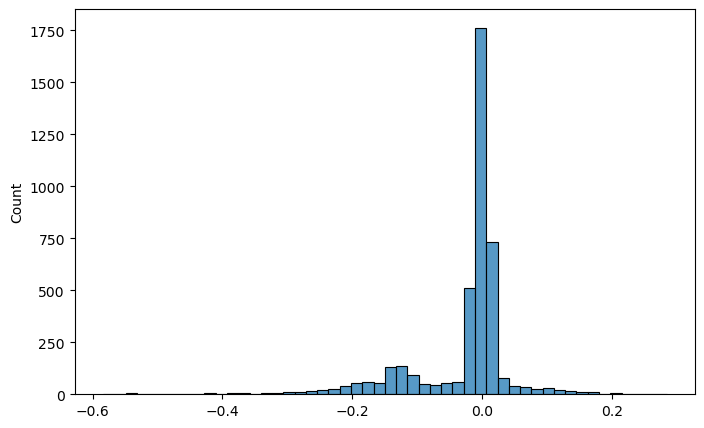

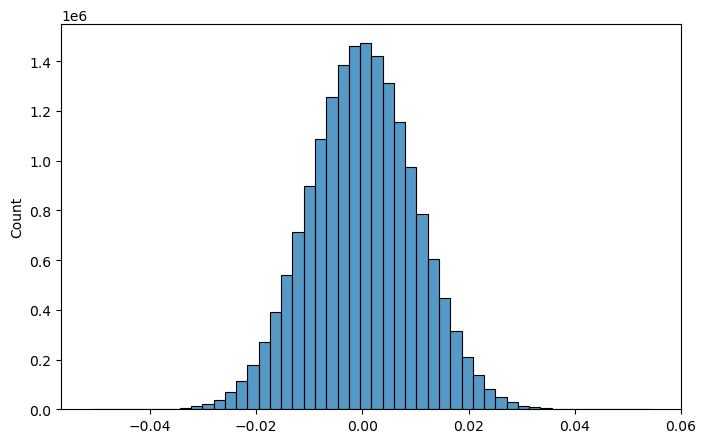

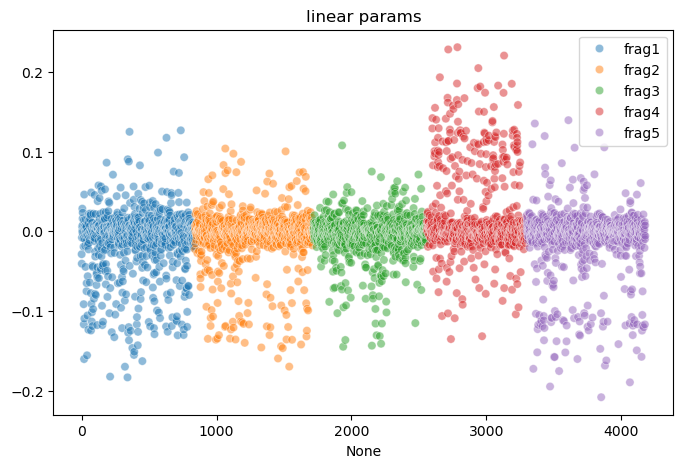

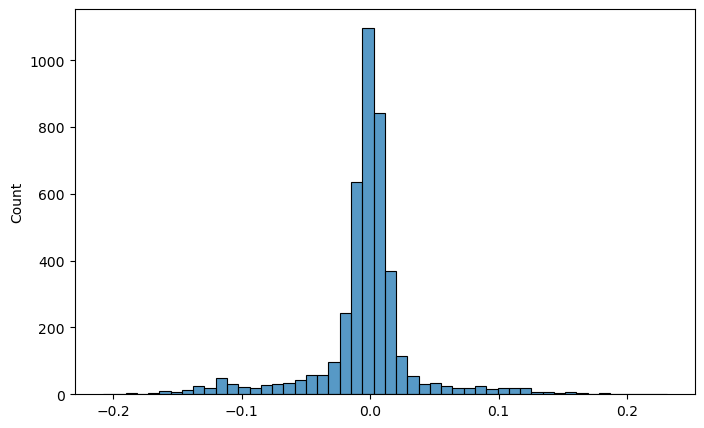

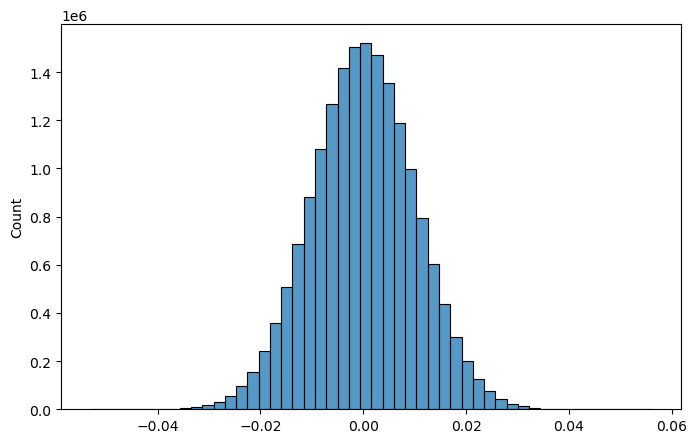

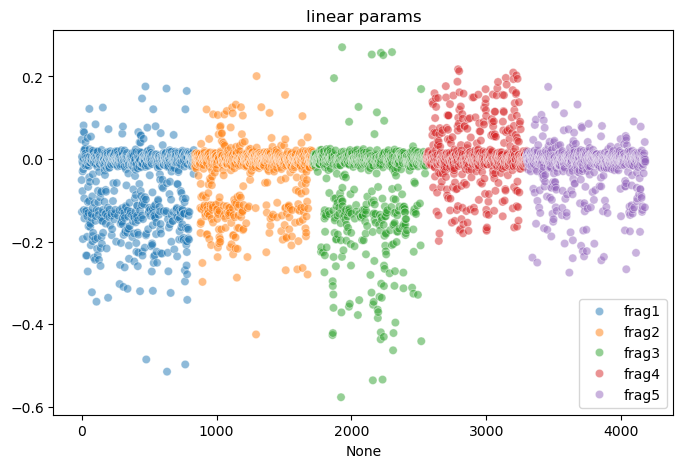

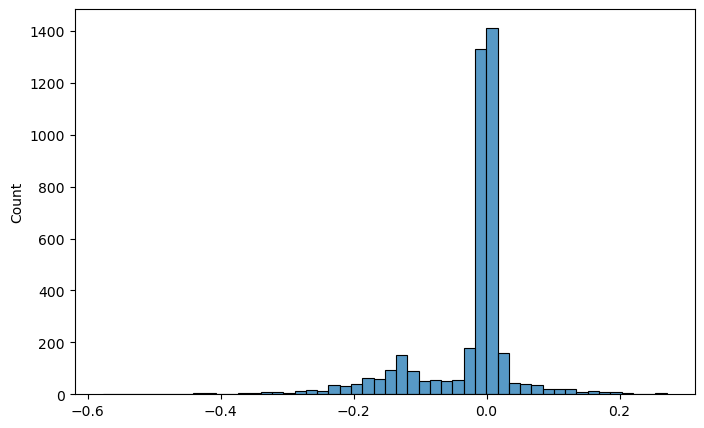

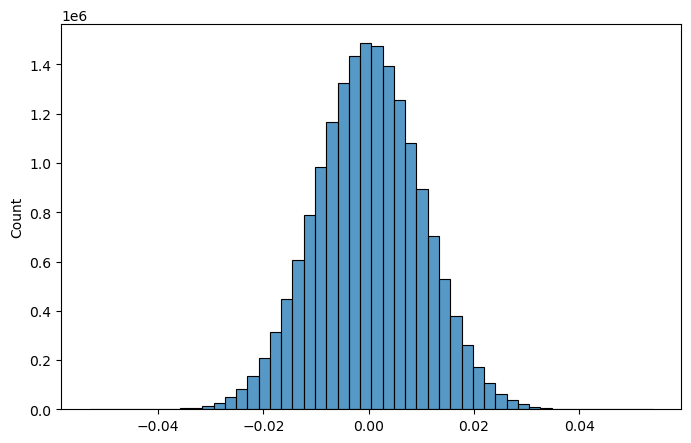

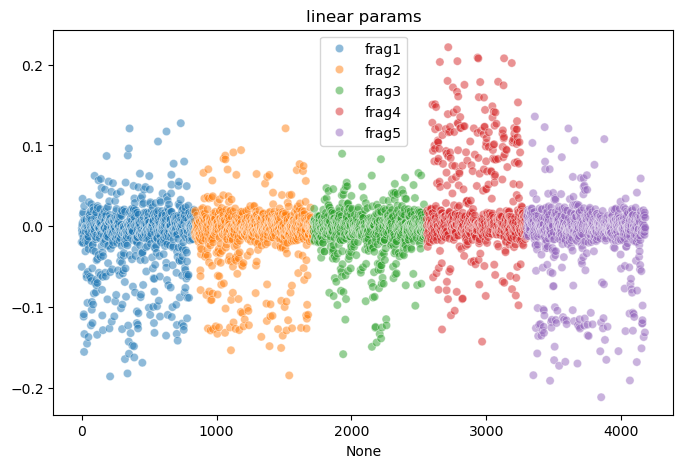

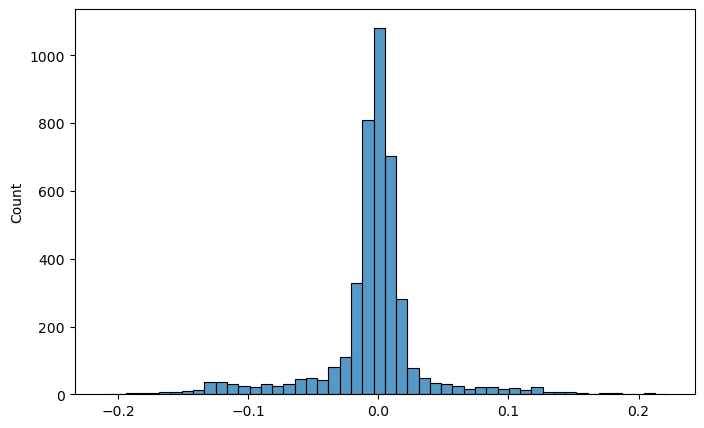

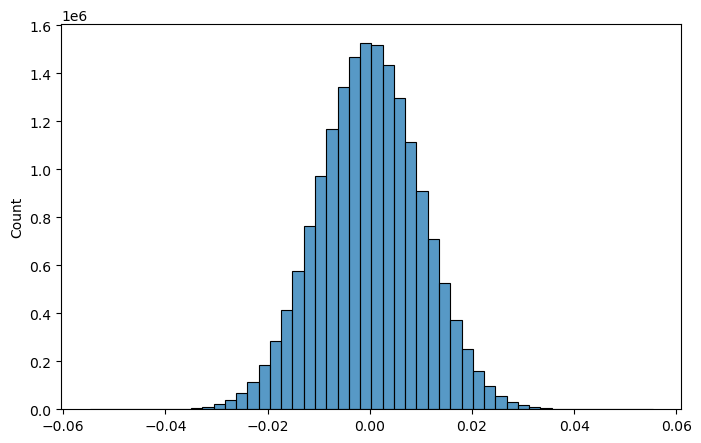

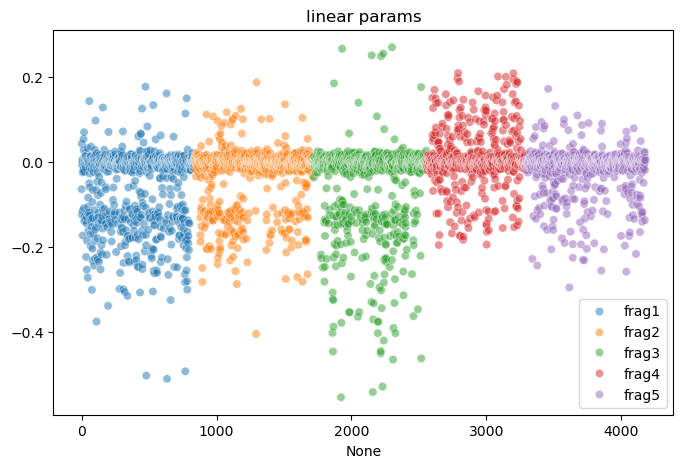

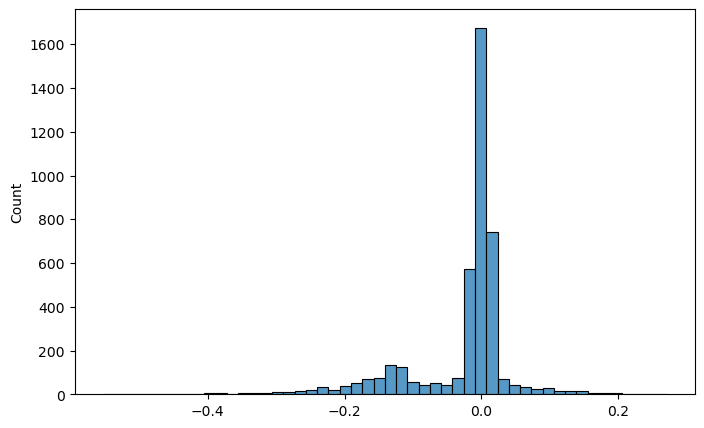

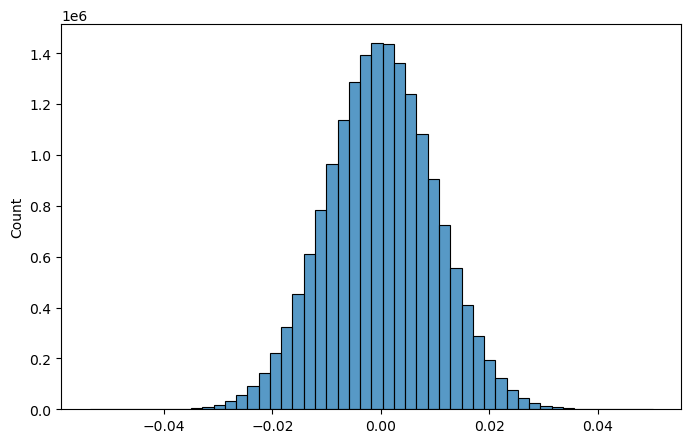

In [679]:


for name, param in model.named_parameters():
    
    if ".h" in name:
        # param is linear head
        y = param.detach().numpy()
        x = torch.arange(y.shape[0])

        plt.figure(figsize=(8,5),dpi=100)
        sns.scatterplot(x=x,y=y, hue=hue_list, alpha=0.5)
        plt.title("linear params")

        plt.figure(figsize=(8,5),dpi=100)
        sns.histplot(x=y,bins=50)
        
    else:

        _map = param.detach().numpy()
        plt.figure(figsize=(8,5),dpi=100)
        sns.histplot(x=_map.reshape(-1),bins=50)


(array([4.800000e+02, 2.671700e+04, 4.994470e+05, 3.155700e+06,
        6.922393e+06, 5.312474e+06, 1.420413e+06, 1.307100e+05,
        4.024000e+03, 4.200000e+01]),
 array([-0.0510387 , -0.04028817, -0.02953764, -0.01878711, -0.00803659,
         0.00271394,  0.01346447,  0.024215  ,  0.03496553,  0.04571606,
         0.05646659]),
 <BarContainer object of 10 artists>)

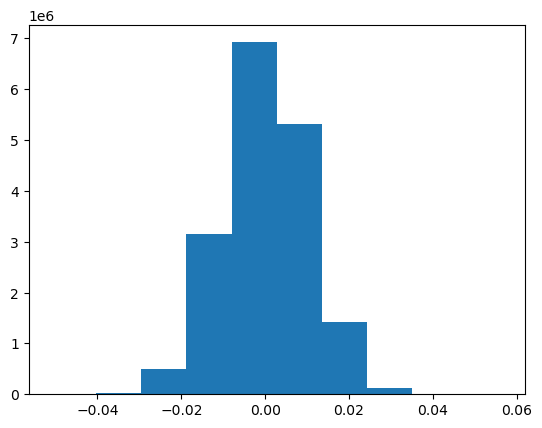

In [641]:
plt.hist(param.detach().numpy().reshape(-1))

In [638]:
param.shape

torch.Size([4180, 4180])